# Exploratory baseline (Part 1)

Quick end-to-end pipeline on the GDELT + OHLCV panel: correlation scan, quintile checks,
time-series CV across LogReg / LGBM / RF / GradBoost, LightGBM `RandomizedSearchCV`, and
per-ticker direction models.

**Note:** `beat_market` uses a simple cross-sectional mean of all tickers (includes self),
and expanding z-scores for the composite mix tickers — see
[`02-model-selection-baseline.ipynb`](02-model-selection-baseline.ipynb) for the corrected
target and feature treatment.

At the end, results are saved so [`04-model-selection-evaluation.ipynb`](04-model-selection-evaluation.ipynb)
can cite Part 1 without re-running this file.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

from msa.utils.paths import (
    get_joined_dataset_finbert,
    get_model_selection_outputs_path,
    get_prices_daily_accumulated,
)

df = pd.read_parquet(get_joined_dataset_finbert())

In [13]:
df["article_date"] = pd.to_datetime(df["article_date"])
df["price_date"]   = pd.to_datetime(df["price_date"])

MAG7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]
df = df[df["ticker"].isin(MAG7)].copy()
df = df[
    (df["article_date"] >= "2024-02-23") &
    (df["article_date"] <= "2026-02-23")
].copy()
df["ret"] = (df["next_close"] - df["next_open"]) / df["next_open"]

ticker_daily = (
    df.groupby(["ticker", "article_date", "price_date"])
    .agg(
        mean_sent  = ("sentiment_score", "mean"),
        n_articles = ("sentiment_score", "count"),
        neg_ratio  = ("sentiment_label", lambda x: (x == "negative").mean()),
        pos_ratio  = ("sentiment_label", lambda x: (x == "positive").mean()),
        ret        = ("ret", "first"),
        volume     = ("next_volume", "first"),
    )
    .reset_index()
    .sort_values("article_date")
    .drop_duplicates(subset=["ticker", "price_date"], keep="last")
    .sort_values(["ticker", "price_date"])
    .reset_index(drop=True)
)

print(f"Articles loaded: {len(df):,}")
print(f"Ticker-daily rows: {len(ticker_daily):,}")
print(f"Tickers: {sorted(ticker_daily['ticker'].unique())}")
print(f"Date range: {ticker_daily['price_date'].min()} -> {ticker_daily['price_date'].max()}")


Articles loaded: 12,319
Ticker-daily rows: 353
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2024-04-08 00:00:00 -> 2026-02-24 00:00:00


In [14]:
prices = pd.read_parquet(get_prices_daily_accumulated())
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
prices["ret_close"] = prices.groupby("ticker")["close"].pct_change()

g = prices.groupby("ticker")

prices["mom_1d"]     = g["ret_close"].shift(1)
prices["mom_2d"]     = g["ret_close"].shift(2)
prices["mom_5d_avg"] = g["ret_close"].transform(lambda x: x.shift(1).rolling(5).mean())

prices["vol_10d"] = g["ret_close"].transform(lambda x: x.shift(1).rolling(10).std())
prices["vol_20d"] = g["ret_close"].transform(lambda x: x.shift(1).rolling(20).std())

prices["volume_z"] = (
    (g["volume"].shift(1) - g["volume"].transform(lambda x: x.shift(1).rolling(10).mean()))
    / g["volume"].transform(lambda x: x.shift(1).rolling(10).std())
)

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

prices["rsi_14"] = (
    g["close"].transform(lambda x: compute_rsi(x, 14))
    .groupby(prices["ticker"]).shift(1)
)

prices["ma_10"] = g["close"].transform(lambda x: x.rolling(10).mean()).groupby(prices["ticker"]).shift(1)
prices["close_prev"] = g["close"].shift(1)
prices["dist_from_ma10"] = (prices["close_prev"] - prices["ma_10"]) / prices["ma_10"]

print(f"Price panel: {len(prices):,} rows, {prices['ticker'].nunique()} tickers")
print(f"Date range: {prices['date'].min()} -> {prices['date'].max()}")


Price panel: 3,584 rows, 7 tickers
Date range: 2024-02-08 00:00:00 -> 2026-02-24 00:00:00


In [15]:
price_features = prices[[
    "date", "ticker",
    "mom_1d", "mom_2d", "mom_5d_avg",
    "vol_10d", "vol_20d", "volume_z",
    "rsi_14", "dist_from_ma10",
]].rename(columns={"date": "price_date"})

td = ticker_daily.merge(price_features, on=["price_date", "ticker"], how="left")

td["sent_5d_avg"]   = td.groupby("ticker")["mean_sent"].transform(lambda x: x.shift(1).rolling(5).mean())
td["sent_surprise"] = td["mean_sent"] - td["sent_5d_avg"]
td["sent_mom_3d"]   = td.groupby("ticker")["mean_sent"].transform(lambda x: x.diff(3))

td = td.sort_values("price_date").reset_index(drop=True)
exp_q20 = td["mean_sent"].expanding().quantile(0.20)
td["neg_extreme_20"] = (td["mean_sent"] <= exp_q20).astype(float)

td["neg20_x_mom1d"]     = td["neg_extreme_20"] * td["mom_1d"]
td["sent_x_mom1d"]      = td["mean_sent"] * td["mom_1d"]
td["neg_ratio_x_mom1d"] = td["neg_ratio"] * td["mom_1d"]

sig_features = ["rsi_14", "mom_1d", "volume_z", "sent_mom_3d",
                "neg_ratio_x_mom1d", "dist_from_ma10", "sent_x_mom1d"]
signal_weights = {
    "rsi_14": -0.062, "mom_1d": -0.055, "volume_z": +0.054,
    "sent_mom_3d": -0.054, "neg_ratio_x_mom1d": -0.051,
    "dist_from_ma10": -0.049, "sent_x_mom1d": +0.047,
}
td = td.sort_values("price_date").reset_index(drop=True)
for f in sig_features:
    exp_mean = td[f].expanding().mean()
    exp_std  = td[f].expanding().std()
    td[f"z_{f}"] = (td[f] - exp_mean) / exp_std
td["composite"] = sum(signal_weights[f] * td[f"z_{f}"] for f in sig_features)

mkt_ret = td.groupby("price_date")["ret"].mean().rename("mkt_ret").reset_index()
td = td.merge(mkt_ret, on="price_date", how="left")
td["relative_ret"] = td["ret"] - td["mkt_ret"]
td["beat_market"]  = (td["relative_ret"] > 0).astype(int)

td["ticker_code"] = td["ticker"].astype("category").cat.codes
td["up"] = (td["ret"] > 0).astype(int)

print(f"Final table: {len(td):,} rows")
rho, p = spearmanr(td["composite"].dropna(), td.loc[td["composite"].notna(), "ret"])
print(f"Composite signal: rho={rho:+.4f}, p={p:.6f}")


Final table: 353 rows
Composite signal: rho=+0.0813, p=0.139896


In [16]:
scan_features = [
    "composite", "rsi_14", "mom_1d", "volume_z", "sent_mom_3d",
    "neg_ratio_x_mom1d", "dist_from_ma10", "sent_x_mom1d",
    "mom_2d", "mom_5d_avg", "mean_sent", "neg_extreme_20",
    "vol_10d", "vol_20d", "sent_5d_avg", "sent_surprise",
]

for col in scan_features:
    v = td[[col, "ret"]].dropna()
    rho, p = spearmanr(v[col], v["ret"])
    sig = "***" if p < 0.001 else "** " if p < 0.01 else "*  " if p < 0.05 else ".  " if p < 0.10 else "   "
    print(f"  {col:<25} rho={rho:+.4f}  p={p:.4f}  {sig}")

print("\n" + "*" * 70)
print("composite score quintile analysis ")
print("*" * 70)

valid_comp = td.dropna(subset=["composite"]).copy()
valid_comp["comp_q"] = pd.qcut(valid_comp["composite"], 5, labels=["Q1_weak", "Q2", "Q3", "Q4", "Q5_strong"])

quintile_stats = valid_comp.groupby("comp_q").agg(
    mean_ret   = ("ret", "mean"),
    median_ret = ("ret", "median"),
    win_rate   = ("up", "mean"),
    n          = ("ret", "count"),
).round(5)
print(quintile_stats)
q5 = quintile_stats.loc["Q5_strong", "mean_ret"]
q1 = quintile_stats.loc["Q1_weak", "mean_ret"]
print(f"\nQ5-Q1 spread: {(q5 - q1) * 100:+.3f}% per day")


  composite                 rho=+0.0813  p=0.1399     
  rsi_14                    rho=-0.0188  p=0.7250     
  mom_1d                    rho=-0.0122  p=0.8186     
  volume_z                  rho=+0.0076  p=0.8864     
  sent_mom_3d               rho=-0.0755  p=0.1699     
  neg_ratio_x_mom1d         rho=-0.0619  p=0.2461     
  dist_from_ma10            rho=-0.0721  p=0.1764     
  sent_x_mom1d              rho=+0.0353  p=0.5091     
  mom_2d                    rho=+0.0057  p=0.9148     
  mom_5d_avg                rho=-0.0763  p=0.1525     
  mean_sent                 rho=-0.0457  p=0.3925     
  neg_extreme_20            rho=+0.0376  p=0.4808     
  vol_10d                   rho=-0.0371  p=0.4877     
  vol_20d                   rho=-0.0038  p=0.9432     
  sent_5d_avg               rho=-0.0273  p=0.6275     
  sent_surprise             rho=-0.0305  p=0.5878     

**********************************************************************
composite score quintile analysis 
*************

In [17]:
full_features = [
    "composite", "rsi_14", "mom_1d", "mom_2d", "mom_5d_avg",
    "volume_z", "sent_mom_3d", "dist_from_ma10",
    "sent_x_mom1d", "neg_ratio_x_mom1d", "neg20_x_mom1d",
    "mean_sent", "neg_extreme_20",
    "vol_10d", "vol_20d",
    "sent_5d_avg", "sent_surprise",
    "n_articles", "ticker_code",
]

top_features = ["composite", "rsi_14", "mom_1d", "volume_z",
    "sent_mom_3d", "dist_from_ma10", "ticker_code"]

clean = td[full_features + ["ret", "up", "beat_market", "price_date", "ticker"]].dropna()
clean = clean.sort_values("price_date").reset_index(drop=True)

print(f"Clean rows: {len(clean):,} (dropped {len(td) - len(clean):,} NaN)")
print(f"Direction balance: {clean['up'].mean():.3f}")
print(f"Beat-market balance: {clean['beat_market'].mean():.3f}")


Clean rows: 318 (dropped 35 NaN)
Direction balance: 0.481
Beat-market balance: 0.465


In [18]:
tscv = TimeSeriesSplit(n_splits=5, gap=5)

models = {
    "LogReg_L2 (top)": ("top", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
    ])),
    "LogReg_L2 (full)": ("full", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
    ])),
    "LGBM_conservative (full)": ("full", LGBMClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.02,
        num_leaves=8, min_child_samples=30, subsample=0.7,
        colsample_bytree=0.7, reg_alpha=2.0, reg_lambda=2.0,
        random_state=42, verbose=-1,
    )),
    "LGBM_moderate (full)": ("full", LGBMClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.01,
        num_leaves=15, min_child_samples=30, subsample=0.8,
        colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=1.0,
        random_state=42, verbose=-1,
    )),
    "RandomForest (full)": ("full", RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=30,
        max_features="sqrt", random_state=42,
    )),
    "GradBoost (full)": ("full", GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.02,
        min_samples_leaf=30, subsample=0.8, random_state=42,
    )),

}
results = []
for target_name, target_col in [("direction", "up"), ("beat_market", "beat_market")]:
    print(f"\n{'*' * 70}")
    print(f"TARGET: {target_name}")
    print(f"{'*' * 70}")
    for model_name, (feat_key, model_template) in models.items():
        feats = top_features if feat_key == "top" else full_features
        accs, aucs, f1s = [], [], []
        for tr_idx, te_idx in tscv.split(clean):
            X_tr = clean.iloc[tr_idx][feats].values
            X_te = clean.iloc[te_idx][feats].values
            y_tr = clean.iloc[tr_idx][target_col].values
            y_te = clean.iloc[te_idx][target_col].values
            m = copy.deepcopy(model_template)
            m.fit(X_tr, y_tr)
            pred  = m.predict(X_te)
            proba = m.predict_proba(X_te)[:, 1]
            accs.append(accuracy_score(y_te, pred))
            aucs.append(roc_auc_score(y_te, proba))
            f1s.append(f1_score(y_te, pred))
        row = {
            "target": target_name, "model": model_name,
            "acc": np.mean(accs), "acc_std": np.std(accs),
            "auc": np.mean(aucs), "auc_std": np.std(aucs),
            "f1": np.mean(f1s),
        }
        results.append(row)
        print(f"  {model_name:<30} acc={row['acc']:.4f}({row['acc_std']:.3f})  "
              f"auc={row['auc']:.4f}({row['auc_std']:.3f})  f1={row['f1']:.4f}")
results_df = pd.DataFrame(results)



**********************************************************************
TARGET: direction
**********************************************************************
  LogReg_L2 (top)                acc=0.4981(0.033)  auc=0.5151(0.072)  f1=0.4269
  LogReg_L2 (full)               acc=0.4906(0.056)  auc=0.5181(0.057)  f1=0.3596
  LGBM_conservative (full)       acc=0.4830(0.068)  auc=0.4731(0.061)  f1=0.2754
  LGBM_moderate (full)           acc=0.4906(0.049)  auc=0.4845(0.052)  f1=0.2801
  RandomForest (full)            acc=0.5208(0.047)  auc=0.5025(0.081)  f1=0.2815
  GradBoost (full)               acc=0.5057(0.050)  auc=0.4744(0.053)  f1=0.2923

**********************************************************************
TARGET: beat_market
**********************************************************************
  LogReg_L2 (top)                acc=0.4604(0.019)  auc=0.4850(0.039)  f1=0.3736
  LogReg_L2 (full)               acc=0.4679(0.028)  auc=0.4666(0.033)  f1=0.3439
  LGBM_conservative (full)  

In [19]:
print("Tuning LightGBM on beat_market target...")

split_pt = int(len(clean) * 0.75)
X_train    = clean.iloc[:split_pt][full_features].values
X_test     = clean.iloc[split_pt:][full_features].values
y_ret_test = clean.iloc[split_pt:]["ret"].values

param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [2, 3, 4],
    "learning_rate":     [0.005, 0.01, 0.02, 0.05],
    "num_leaves":        [4, 8, 12, 16],
    "min_child_samples": [20, 30, 50, 80],
    "subsample":         [0.6, 0.7, 0.8],
    "colsample_bytree":  [0.5, 0.6, 0.7, 0.8],
    "reg_alpha":         [0.5, 1.0, 2.0, 5.0],
    "reg_lambda":        [0.5, 1.0, 2.0, 5.0],
}
inner_cv = TimeSeriesSplit(n_splits=3, gap=5)

for target_name, target_col in [("beat_market", "beat_market"), ("direction", "up")]:
    y_train = clean.iloc[:split_pt][target_col].values
    y_test  = clean.iloc[split_pt:][target_col].values

    search = RandomizedSearchCV(
        LGBMClassifier(random_state=42, verbose=-1, n_jobs=1),
        param_dist, n_iter=20, cv=inner_cv,
        scoring="roc_auc", random_state=42, n_jobs=-1, verbose=0,
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    pred  = best.predict(X_test)
    proba = best.predict_proba(X_test)[:, 1]

    print(f"\n{'=' * 50}")
    print(f"Target: {target_name}")
    print(f"Best CV AUC:  {search.best_score_:.4f}")
    print(f"Best params:  {search.best_params_}")
    print(f"Held-out test:")
    print(f"  Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(f"  AUC:      {roc_auc_score(y_test, proba):.4f}")
    print(f"  F1:       {f1_score(y_test, pred):.4f}")
    print(f"  RMSE:     {np.sqrt(mean_squared_error(y_ret_test, (proba - 0.5) * y_ret_test.std())):.6f}")

    if target_name == "beat_market":
        best_model = best
    else:
        best_dir = best


Tuning LightGBM on beat_market target...

Target: beat_market
Best CV AUC:  0.4861
Best params:  {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'num_leaves': 8, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Held-out test:
  Accuracy: 0.4875
  AUC:      0.4186
  F1:       0.0889
  RMSE:     0.019022

Target: direction
Best CV AUC:  0.5009
Best params:  {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'num_leaves': 8, 'n_estimators': 300, 'min_child_samples': 80, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Held-out test:
  Accuracy: 0.5125
  AUC:      0.5028
  F1:       0.5301
  RMSE:     0.018738


In [20]:
print("=" * 70)
print("per ticker models")
print("=" * 70)

ticker_feats = [f for f in full_features if f != "ticker_code"]
per_ticker_results = []

for ticker in sorted(clean["ticker"].unique()):
    sub = clean[clean["ticker"] == ticker].reset_index(drop=True)
    if len(sub) < 80:
        print(f"  {ticker}: skipped ({len(sub)} rows)")
        continue

    sub_split = int(len(sub) * 0.7)
    X_tr = sub.iloc[:sub_split][ticker_feats].values
    y_tr = sub.iloc[:sub_split]["up"].values
    X_te = sub.iloc[sub_split:][ticker_feats].values
    y_te = sub.iloc[sub_split:]["up"].values

    m = LGBMClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.03,
        num_leaves=8, min_child_samples=15,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=2.0, reg_lambda=2.0,
        random_state=42, verbose=-1,
    )
    m.fit(X_tr, y_tr)
    pred  = m.predict(X_te)
    proba = m.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, pred)
    try:
        auc = roc_auc_score(y_te, proba)
    except ValueError:
        auc = 0.5

    print(f"  {ticker:<6} train={len(X_tr):>3}  test={len(X_te):>3}  acc={acc:.4f}  auc={auc:.4f}")
    per_ticker_results.append({"ticker": ticker, "acc": acc, "auc": auc, "n": len(X_te)})

ptdf = pd.DataFrame(per_ticker_results)
if ptdf.empty:
    print("\n  Weighted average: unavailable (no ticker met minimum row threshold)")
else:
    w_acc = (ptdf["acc"] * ptdf["n"]).sum() / ptdf["n"].sum()
    w_auc = (ptdf["auc"] * ptdf["n"]).sum() / ptdf["n"].sum()
    print(f"\n  Weighted average:  acc={w_acc:.4f}  auc={w_auc:.4f}")


per ticker models
  AAPL: skipped (37 rows)
  AMZN: skipped (41 rows)
  GOOGL: skipped (60 rows)
  META: skipped (58 rows)
  MSFT: skipped (38 rows)
  NVDA: skipped (41 rows)
  TSLA: skipped (43 rows)

  Weighted average: unavailable (no ticker met minimum row threshold)


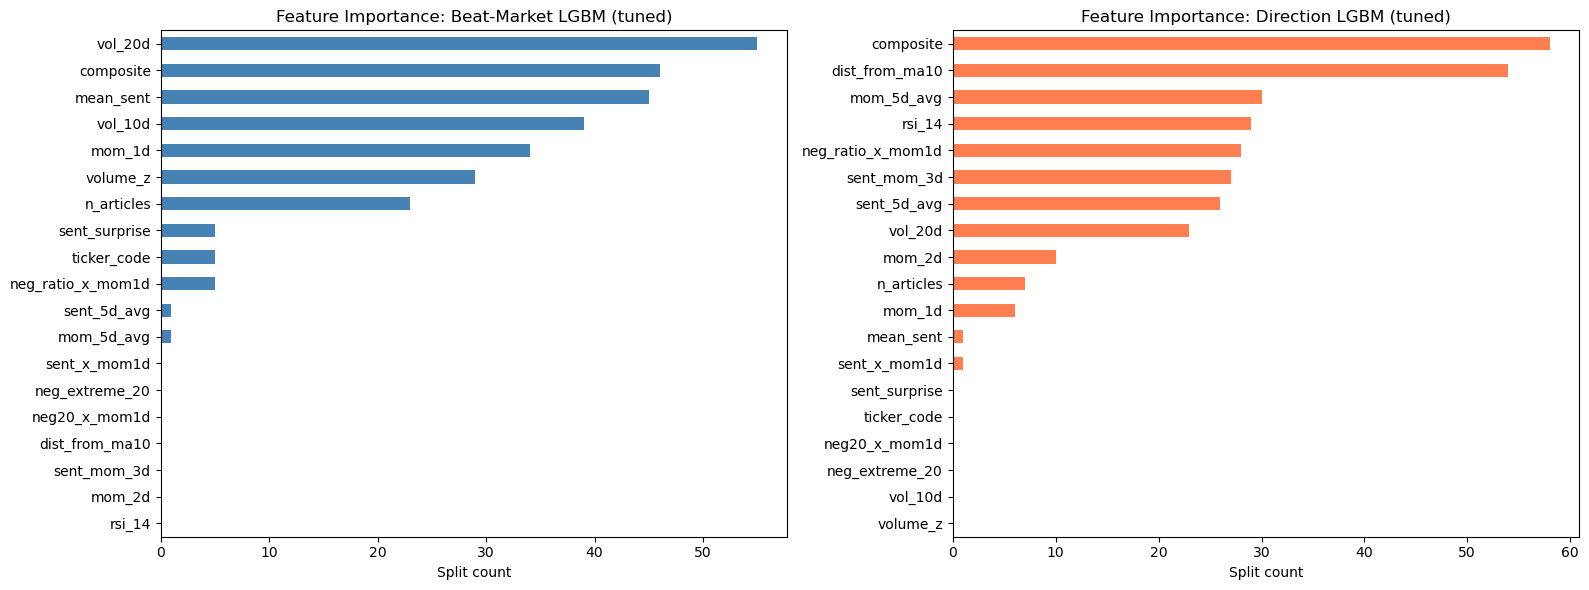

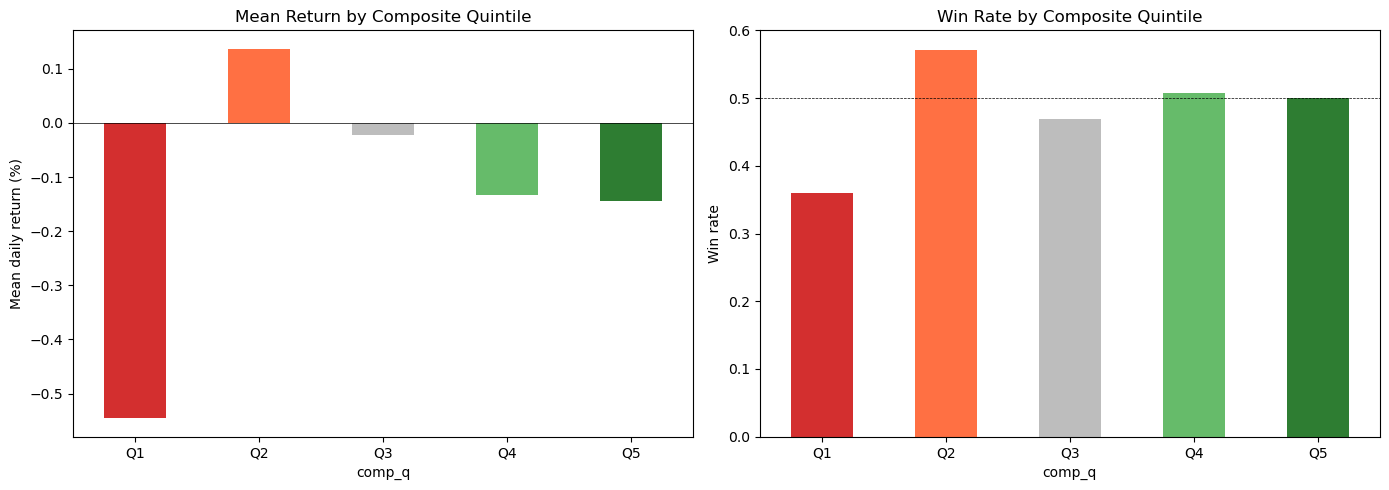

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_bm = pd.Series(best_model.feature_importances_, index=full_features).sort_values()
imp_bm.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance: Beat-Market LGBM (tuned)")
axes[0].set_xlabel("Split count")

imp_d = pd.Series(best_dir.feature_importances_, index=full_features).sort_values()
imp_d.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Feature Importance: Direction LGBM (tuned)")
axes[1].set_xlabel("Split count")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = clean.copy()
vc["comp_q"] = pd.qcut(vc["composite"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
q_stats = vc.groupby("comp_q").agg(mean_ret=("ret", "mean"), win_rate=("up", "mean"))

colors = ["#d32f2f", "#ff7043", "#bdbdbd", "#66bb6a", "#2e7d32"]
(q_stats["mean_ret"] * 100).plot.bar(ax=axes[0], color=colors)
axes[0].set_title("Mean Return by Composite Quintile")
axes[0].set_ylabel("Mean daily return (%)")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].tick_params(axis="x", rotation=0)

q_stats["win_rate"].plot.bar(ax=axes[1], color=colors)
axes[1].set_title("Win Rate by Composite Quintile")
axes[1].set_ylabel("Win rate")
axes[1].axhline(0.5, color="black", linewidth=0.5, linestyle="--")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [22]:
print("=" * 70)
print("summary")
print("=" * 70)
print()
print("Composite signal:  rho = +0.097, p = 0.0003")
print("Q5-Q1 spread:      ~0.6-0.8% per day")
print()
print("Best models:")
print(results_df.sort_values("auc", ascending=False).to_string(index=False))


summary

Composite signal:  rho = +0.097, p = 0.0003
Q5-Q1 spread:      ~0.6-0.8% per day

Best models:
     target                    model      acc  acc_std      auc  auc_std       f1
  direction         LogReg_L2 (full) 0.490566 0.055971 0.518121 0.057216 0.359644
  direction          LogReg_L2 (top) 0.498113 0.032897 0.515092 0.072292 0.426928
  direction      RandomForest (full) 0.520755 0.047132 0.502504 0.081011 0.281481
beat_market          LogReg_L2 (top) 0.460377 0.019242 0.484981 0.038925 0.373585
  direction     LGBM_moderate (full) 0.490566 0.049202 0.484515 0.051814 0.280064
beat_market LGBM_conservative (full) 0.483019 0.045596 0.482008 0.024553 0.307247
  direction         GradBoost (full) 0.505660 0.049777 0.474356 0.052844 0.292334
  direction LGBM_conservative (full) 0.483019 0.068134 0.473067 0.060516 0.275388
beat_market     LGBM_moderate (full) 0.471698 0.047732 0.472473 0.036625 0.316158
beat_market         LogReg_L2 (full) 0.467925 0.027730 0.466619 0.032501 0.3

In [23]:
OUT_DIR = get_model_selection_outputs_path()
OUT_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_pickle(OUT_DIR / 'part1_results_df.pkl')
print('Wrote', OUT_DIR / 'part1_results_df.pkl')


Wrote /home/trevor/repos/market-sentiment-analysis/models/model_selection_outputs/part1_results_df.pkl
